In [ ]:
import mne
from mne.datasets import eegbci

subject = 1
runs = [6, 10, 14]

files = eegbci.load_data(subject, runs)

print(files)

Using default location ~/mne_data for EEGBCI...
Creating /Users/otiliabalan/mne_data


In [1]:
import mne
from mne.datasets import eegbci

files = eegbci.load_data(1, [6])
print(files)

Using default location ~/mne_data for EEGBCI...
Attempting to create new mne-python configuration file:
/Users/otiliabalan/.mne/mne-python.json
Could not read the /Users/otiliabalan/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
[PosixPath('/Users/otiliabalan/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R06.edf')]


In [2]:
files = eegbci.load_data(1, [6, 10, 14])

raws = [
    mne.io.read_raw_edf(file, preload=True)
    for file in files
]

raw = mne.concatenate_raws(raws)

print(raw)
print(raw.info)

Extracting EDF parameters from /Users/otiliabalan/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R06.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from /Users/otiliabalan/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R10.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from /Users/otiliabalan/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R14.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
<RawEDF | S001R06.edf, 64 x 60000 (375.0 s), ~29.4 MiB, data loaded>
<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 

Using matplotlib as 2D backend.


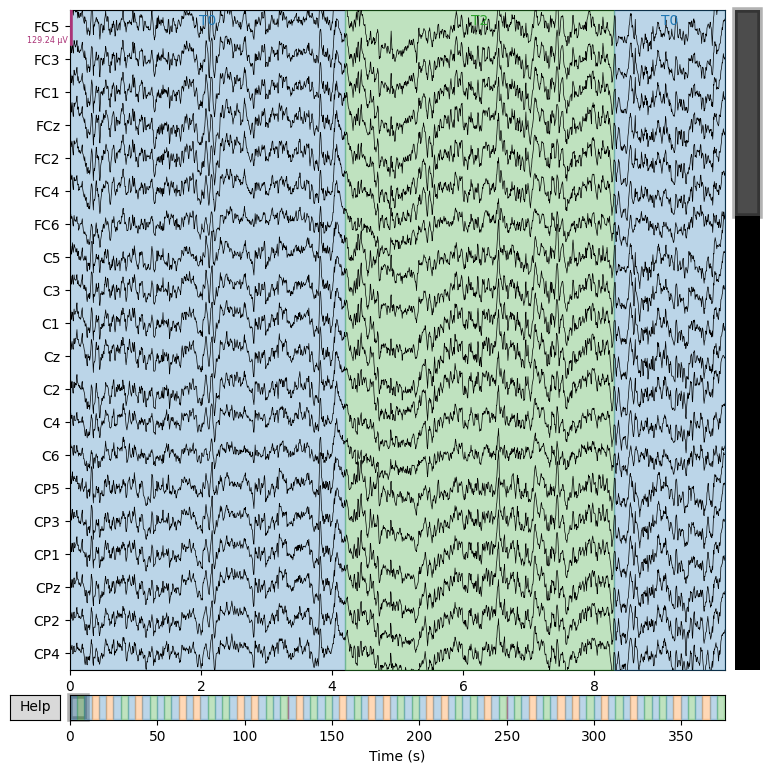

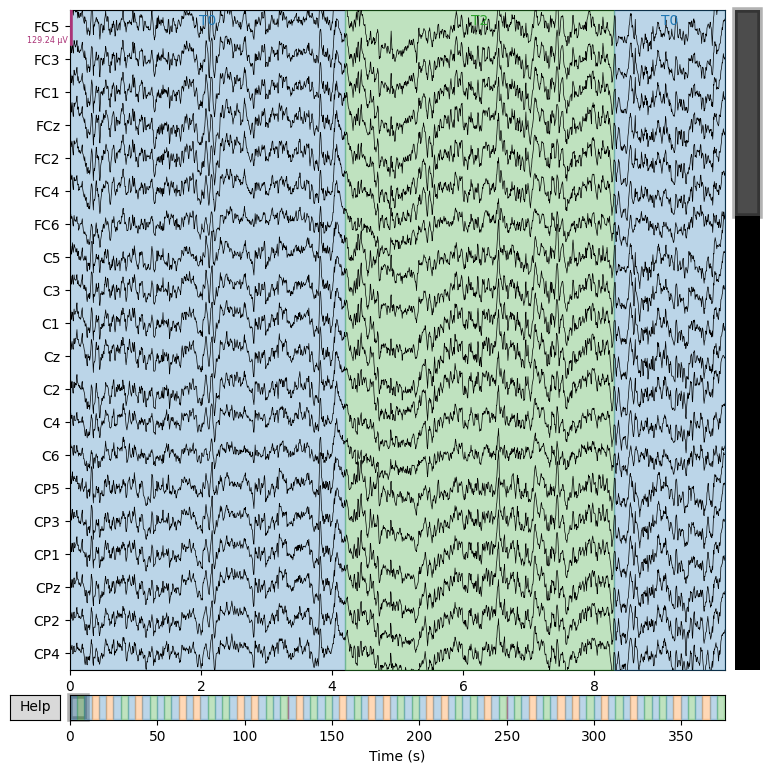

In [3]:
# Clean up the EEG channel names
eegbci.standardize(raw)

# Tell MNE where the electrodes are located on the head
montage = mne.channels.make_standard_montage("standard_1005")
raw.set_montage(montage)

# Look at 10 seconds of EEG
raw.plot(
    duration=10,
    n_channels=20,
    scalings="auto"
)

In [4]:
print(raw.annotations)
print(set(raw.annotations.description))

<Annotations | 94 segments: BAD boundary (2), EDGE boundary (2), T0 (45), ...>
{np.str_('BAD boundary'), np.str_('EDGE boundary'), np.str_('T0'), np.str_('T2'), np.str_('T1')}


In [5]:
events, event_id = mne.events_from_annotations(
    raw,
    event_id={"T1": 1, "T2": 2}
)

print(event_id)
print(events[:10])
print("Number of trials:", len(events))

Used Annotations descriptions: [np.str_('T1'), np.str_('T2')]
{np.str_('T1'): 1, np.str_('T2'): 2}
[[  672     0     2]
 [ 2000     0     1]
 [ 3328     0     1]
 [ 4656     0     2]
 [ 5984     0     1]
 [ 7312     0     2]
 [ 8640     0     2]
 [ 9968     0     1]
 [11296     0     1]
 [12624     0     2]]
Number of trials: 45


In [6]:
# Keep the original raw data untouched
raw_filtered = raw.copy()

# Keep frequencies from 7 to 30 Hz
raw_filtered.filter(7.0, 30.0)

# Cut continuous EEG into individual trials
epochs = mne.Epochs(
    raw_filtered,
    events,
    event_id={"hands": 1, "feet": 2},
    tmin=-1.0,
    tmax=4.0,
    baseline=None,
    preload=True
)

print(epochs)
print("Hands trials:", len(epochs["hands"]))
print("Feet trials:", len(epochs["feet"]))

Filtering raw data in 3 contiguous segments
Setting up band-pass filter from 7 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 7.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 6.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 265 samples (1.656 s)

Not setting metadata
45 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 45 events and 801 original time points ...
0 bad epochs dropped
<Epochs | 45 events (all good), -1 – 4 s (baseline off), ~17.7 MiB, data loaded,
 'hands': 21
 'feet': 24>
Hands trials: 21
Feet trials: 24


In [7]:
import numpy as np

# Use 1–2 seconds after each movement-imagery cue
epochs_train = epochs.copy().crop(tmin=1.0, tmax=2.0)

# X = EEG measurements
X = epochs_train.get_data()

# y = labels: 1 = hands, 2 = feet
y = epochs_train.events[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Labels:", y)


X shape: (45, 64, 161)
y shape: (45,)
Labels: [2 1 1 2 1 2 2 1 1 2 2 1 1 2 2 1 2 2 1 2 1 1 2 2 1 1 2 2 1 2 2 1 2 1 1 2 1
 2 1 2 2 1 2 1 2]


In [8]:
from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedShuffleSplit, cross_val_score
from sklearn.pipeline import make_pipeline

csp = CSP(
    n_components=4,
    reg=None,
    log=True,
    norm_trace=False
)

lda = LinearDiscriminantAnalysis()

classifier = make_pipeline(csp, lda)

cv = StratifiedShuffleSplit(
    n_splits=10,
    test_size=0.2,
    random_state=42
)

scores = cross_val_score(
    classifier,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Accuracy for each split:", scores)
print("Mean accuracy:", scores.mean())
print("Standard deviation:", scores.std())

Computing rank from data with rank=None
    Using tolerance 0.00015 (2.2e-16 eps * 64 dim * 1.1e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00015 (2.2e-16 eps * 64 dim * 1.1e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00015 (2.2e-16 eps * 64 dim * 1.1e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=1 covariance using EMP

/Users/otiliabalan/Desktop/eeg_motor_imagery/.venv/lib/python3.10/site-packages/mne/decoding/_ged.py:47: RuntimeWarning: divide by zero encountered in matmul
  S_restr = restr_mat @ S @ restr_mat.T
/Users/otiliabalan/Desktop/eeg_motor_imagery/.venv/lib/python3.10/site-packages/mne/decoding/_ged.py:47: RuntimeWarning: overflow encountered in matmul
  S_restr = restr_mat @ S @ restr_mat.T
/Users/otiliabalan/Desktop/eeg_motor_imagery/.venv/lib/python3.10/site-packages/mne/decoding/_ged.py:47: RuntimeWarning: invalid value encountered in matmul
  S_restr = restr_mat @ S @ restr_mat.T
/Users/otiliabalan/Desktop/eeg_motor_imagery/.venv/lib/python3.10/site-packages/mne/decoding/_ged.py:48: RuntimeWarning: divide by zero encountered in matmul
  R_restr = restr_mat @ R @ restr_mat.T
/Users/otiliabalan/Desktop/eeg_motor_imagery/.venv/lib/python3.10/site-packages/mne/decoding/_ged.py:48: RuntimeWarning: overflow encountered in matmul
  R_restr = restr_mat @ R @ restr_mat.T
/Users/otiliabalan/Desk

In [9]:
from sklearn.model_selection import LeaveOneGroupOut

groups = np.repeat([0, 1, 2], 15)

logo = LeaveOneGroupOut()

run_scores = cross_val_score(
    classifier,
    X,
    y,
    cv=logo,
    groups=groups,
    scoring="accuracy"
)

print("Accuracy for each held out run:", run_scores)
print("Mean held out run accuracy:", run_scores.mean())

Computing rank from data with rank=None
    Using tolerance 0.00013 (2.2e-16 eps * 64 dim * 9.1e+09  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00014 (2.2e-16 eps * 64 dim * 9.8e+09  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00014 (2.2e-16 eps * 64 dim * 1e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=1 covariance using EMPIR

/Users/otiliabalan/Desktop/eeg_motor_imagery/.venv/lib/python3.10/site-packages/mne/decoding/_ged.py:47: RuntimeWarning: divide by zero encountered in matmul
  S_restr = restr_mat @ S @ restr_mat.T
/Users/otiliabalan/Desktop/eeg_motor_imagery/.venv/lib/python3.10/site-packages/mne/decoding/_ged.py:47: RuntimeWarning: overflow encountered in matmul
  S_restr = restr_mat @ S @ restr_mat.T
/Users/otiliabalan/Desktop/eeg_motor_imagery/.venv/lib/python3.10/site-packages/mne/decoding/_ged.py:47: RuntimeWarning: invalid value encountered in matmul
  S_restr = restr_mat @ S @ restr_mat.T
/Users/otiliabalan/Desktop/eeg_motor_imagery/.venv/lib/python3.10/site-packages/mne/decoding/_ged.py:48: RuntimeWarning: divide by zero encountered in matmul
  R_restr = restr_mat @ R @ restr_mat.T
/Users/otiliabalan/Desktop/eeg_motor_imagery/.venv/lib/python3.10/site-packages/mne/decoding/_ged.py:48: RuntimeWarning: overflow encountered in matmul
  R_restr = restr_mat @ R @ restr_mat.T
/Users/otiliabalan/Desk

In [13]:
motor_channels = [
    "FC3", "FC1", "FCz", "FC2", "FC4",
    "C3", "C1", "Cz", "C2", "C4",
    "CP3", "CP1", "CPz", "CP2", "CP4"
]

csp = CSP(
    n_components=4,
    reg="ledoit_wolf",
    log=True,
    norm_trace=False
)

classifier = make_pipeline(csp, lda)

bands = {
    "8 to 13 Hz": (8, 13),
    "13 to 30 Hz": (13, 30),
    "8 to 30 Hz": (8, 30)
}

for name, (low, high) in bands.items():

    band_raw = raw.copy()
    band_raw.pick(motor_channels)
    band_raw.filter(low, high)

    band_epochs = mne.Epochs(
        band_raw,
        events,
        event_id={"hands": 1, "feet": 2},
        tmin=-1,
        tmax=4,
        baseline=None,
        preload=True,
        verbose=False
    )

    band_epochs.crop(tmin=1, tmax=2)

    X_band = band_epochs.get_data()
    y_band = band_epochs.events[:, -1]

    scores = cross_val_score(
        classifier,
        X_band,
        y_band,
        cv=logo,
        groups=groups,
        scoring="accuracy"
    )

    print(name)
    print("Run accuracies:", scores)
    print("Mean accuracy:", scores.mean())
    print()

Filtering raw data in 3 contiguous segments
Setting up band-pass filter from 8 - 13 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 13.00 Hz
- Upper transition bandwidth: 3.25 Hz (-6 dB cutoff frequency: 14.62 Hz)
- Filter length: 265 samples (1.656 s)

Computing rank from data with rank=None
    Using tolerance 1.3e-05 (2.2e-16 eps * 15 dim * 3.9e+09  max singular value)
    Estimated rank (data): 15
    data: rank 15 computed from 15 data channels with 0 projectors
Reducing data rank from 15 -> 15
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Estimating class=2 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 1.3e-05 (2.2e-16 eps

/Users/otiliabalan/Desktop/eeg_motor_imagery/.venv/lib/python3.10/site-packages/mne/decoding/_ged.py:47: RuntimeWarning: divide by zero encountered in matmul
  S_restr = restr_mat @ S @ restr_mat.T
/Users/otiliabalan/Desktop/eeg_motor_imagery/.venv/lib/python3.10/site-packages/mne/decoding/_ged.py:47: RuntimeWarning: overflow encountered in matmul
  S_restr = restr_mat @ S @ restr_mat.T
/Users/otiliabalan/Desktop/eeg_motor_imagery/.venv/lib/python3.10/site-packages/mne/decoding/_ged.py:47: RuntimeWarning: invalid value encountered in matmul
  S_restr = restr_mat @ S @ restr_mat.T
/Users/otiliabalan/Desktop/eeg_motor_imagery/.venv/lib/python3.10/site-packages/mne/decoding/_ged.py:48: RuntimeWarning: divide by zero encountered in matmul
  R_restr = restr_mat @ R @ restr_mat.T
/Users/otiliabalan/Desktop/eeg_motor_imagery/.venv/lib/python3.10/site-packages/mne/decoding/_ged.py:48: RuntimeWarning: overflow encountered in matmul
  R_restr = restr_mat @ R @ restr_mat.T
/Users/otiliabalan/Desk

In [11]:
csp = CSP(
    n_components=4,
    reg="ledoit_wolf",
    log=True,
    norm_trace=False
)

classifier = make_pipeline(csp, lda)

In [14]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import numpy as np

motor_channels = [
    "FC3", "FC1", "FCz", "FC2", "FC4",
    "C3", "C1", "Cz", "C2", "C4",
    "CP3", "CP1", "CPz", "CP2", "CP4"
]

bands = {
    "8 to 13 Hz": (8, 13),
    "13 to 30 Hz": (13, 30),
    "8 to 30 Hz": (8, 30)
}

classifier = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

for name, (low, high) in bands.items():

    band_raw = raw.copy()
    band_raw.pick(motor_channels)
    band_raw.filter(low, high, verbose=False)

    band_epochs = mne.Epochs(
        band_raw,
        events,
        event_id={"hands": 1, "feet": 2},
        tmin=1,
        tmax=2,
        baseline=None,
        preload=True,
        verbose=False
    )

    X_eeg = band_epochs.get_data()

    # Feature = log signal power for each electrode
    X_features = np.log(np.var(X_eeg, axis=2) + 1e-12)

    y_band = band_epochs.events[:, -1]

    scores = cross_val_score(
        classifier,
        X_features,
        y_band,
        cv=logo,
        groups=groups,
        scoring="accuracy"
    )

    print(name)
    print("Run accuracies:", scores)
    print("Mean accuracy:", scores.mean())
    print()

8 to 13 Hz
Run accuracies: [0.73333333 0.73333333 0.8       ]
Mean accuracy: 0.7555555555555555

13 to 30 Hz
Run accuracies: [0.86666667 0.8        0.93333333]
Mean accuracy: 0.8666666666666667

8 to 30 Hz
Run accuracies: [0.8        0.73333333 0.8       ]
Mean accuracy: 0.7777777777777777



In [15]:
def analyze_subject(subject):

    runs = [6, 10, 14]

    motor_channels = [
        "FC3", "FC1", "FCz", "FC2", "FC4",
        "C3", "C1", "Cz", "C2", "C4",
        "CP3", "CP1", "CPz", "CP2", "CP4"
    ]

    bands = {
        "8 to 13 Hz": (8, 13),
        "13 to 30 Hz": (13, 30),
        "8 to 30 Hz": (8, 30)
    }

    results = {}

    for band_name, (low, high) in bands.items():

        X_all = []
        y_all = []
        groups_all = []

        for run_number, run in enumerate(runs):

            # Download this subject's recording
            files = eegbci.load_data(subject, [run])

            raw_run = mne.io.read_raw_edf(
                files[0],
                preload=True,
                verbose=False
            )

            eegbci.standardize(raw_run)

            # Keep only motor-area electrodes
            raw_run.pick(motor_channels)

            # Keep only the frequency band we are testing
            raw_run.filter(
                low,
                high,
                verbose=False
            )

            # Find hands and feet events
            events_run, _ = mne.events_from_annotations(
                raw_run,
                event_id={"T1": 1, "T2": 2},
                verbose=False
            )

            # Take EEG 1–2 seconds after each cue
            epochs_run = mne.Epochs(
                raw_run,
                events_run,
                event_id={"hands": 1, "feet": 2},
                tmin=1,
                tmax=2,
                baseline=None,
                preload=True,
                verbose=False
            )

            X_eeg = epochs_run.get_data()

            # Calculate log power for every electrode
            X_features = np.log(
                np.var(X_eeg, axis=2) + 1e-12
            )

            y = epochs_run.events[:, -1]

            X_all.append(X_features)
            y_all.append(y)

            # Remember which recording run every trial came from
            groups_all.extend(
                [run_number] * len(y)
            )

        X_all = np.concatenate(X_all)
        y_all = np.concatenate(y_all)
        groups_all = np.array(groups_all)

        classifier = make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=1000)
        )

        logo = LeaveOneGroupOut()

        scores = cross_val_score(
            classifier,
            X_all,
            y_all,
            cv=logo,
            groups=groups_all,
            scoring="accuracy"
        )

        results[band_name] = scores.mean()

    return results

In [16]:
subject1 = analyze_subject(1)
print(subject1)


{'8 to 13 Hz': np.float64(0.7555555555555555), '13 to 30 Hz': np.float64(0.8666666666666667), '8 to 30 Hz': np.float64(0.7777777777777777)}


In [17]:
all_results = {}

for subject in range(1, 11):

    print("Analyzing subject", subject)

    all_results[subject] = analyze_subject(subject)

print(all_results)

Analyzing subject 1
Analyzing subject 2


Download complete in 16s (2.4 MB)


Download complete in 15s (2.4 MB)


Download complete in 18s (2.4 MB)
Analyzing subject 3


Download complete in 16s (2.5 MB)


...

Download complete in 17s (2.4 MB)
Analyzing subject 10


Download complete in 22s (2.4 MB)


Failed to download 'S010R10.edf'. Will attempt the download again 2 more times.


Download complete in 04m27s (2.4 MB)


Download complete in 17s (2.4 MB)
{1: {'8 to 13 Hz': np.float64(0.7555555555555555), '13 to 30 Hz': np.float64(0.8666666666666667), '8 to 30 Hz': np.float64(0.7777777777777777)}, 2: {'8 to 13 Hz': np.float64(0.7111111111111111), '13 to 30 Hz': np.float64(0.6888888888888888), '8 to 30 Hz': np.float64(0.6444444444444444)}, 3: {'8 to 13 Hz': np.float64(0.7111111111111111), '13 to 30 Hz': np.float64(0.48888888888888893), '8 to 30 Hz': np.float64(0.6666666666666666)}, 4: {'8 to 13 Hz': np.float64(0.6888888888888888), '13 to 30 Hz': np.float64(0.6), '8 to 30 Hz': np.float64(0.6222222222222222)}, 5: {'8 to 13 Hz': np.float64(0.6), '13 to 30 Hz': np.float64(0.5333333333333333), '8 to 30 Hz': np.float64(0.5111111111111111)}, 6: {'8 to 13 Hz': np.float64(0.48888888888888893), '13 to 30 Hz': np.float64(0.6444444444444444), '8 to 30 Hz': np.float64(0.5111111111111111)}, 7: {'8 to 13 Hz': np.float64(0.8000000000000002), '13 to 30 Hz': np.float64(0.8666666666666667), '8 to 30 Hz': np.float64(0.77777

In [18]:
import pandas as pd

results_df = pd.DataFrame(all_results).T

results_df.index.name = "Subject"

print(results_df)

         8 to 13 Hz  13 to 30 Hz  8 to 30 Hz
Subject                                     
1          0.755556     0.866667    0.777778
2          0.711111     0.688889    0.644444
3          0.711111     0.488889    0.666667
4          0.688889     0.600000    0.622222
5          0.600000     0.533333    0.511111
6          0.488889     0.644444    0.511111
7          0.800000     0.866667    0.777778
8          0.622222     0.666667    0.644444
9          0.511111     0.533333    0.600000
10         0.711111     0.422222    0.555556


In [19]:
print("Mean accuracy across subjects:")
print(results_df.mean())

print("\nStandard deviation:")
print(results_df.std())


Mean accuracy across subjects:
8 to 13 Hz     0.660000
13 to 30 Hz    0.631111
8 to 30 Hz     0.631111
dtype: float64

Standard deviation:
8 to 13 Hz     0.102131
13 to 30 Hz    0.148961
8 to 30 Hz     0.094397
dtype: float64


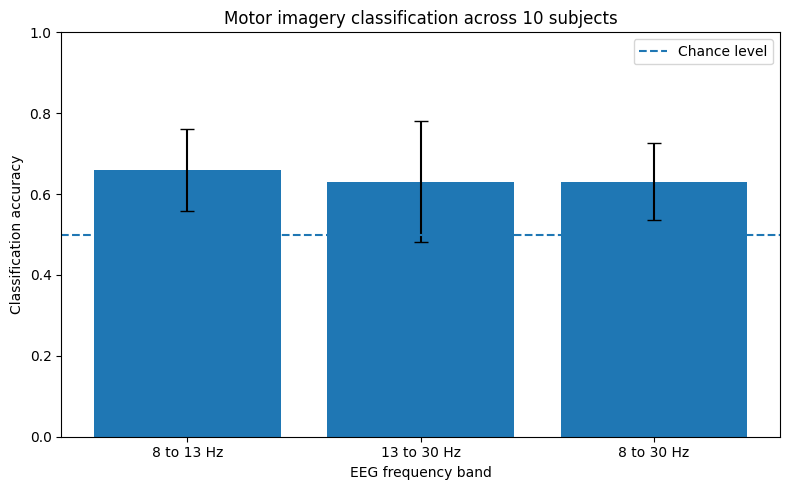

In [20]:
import matplotlib.pyplot as plt

means = results_df.mean()
stds = results_df.std()

plt.figure(figsize=(8, 5))

plt.bar(
    means.index,
    means.values,
    yerr=stds.values,
    capsize=5
)

plt.axhline(
    0.5,
    linestyle="--",
    label="Chance level"
)

plt.ylabel("Classification accuracy")
plt.xlabel("EEG frequency band")
plt.title("Motor imagery classification across 10 subjects")

plt.ylim(0, 1)

plt.legend()
plt.tight_layout()

plt.show()

In [21]:
subject1 = analyze_subject(1)
print(subject1)

{'8 to 13 Hz': np.float64(0.7555555555555555), '13 to 30 Hz': np.float64(0.8666666666666667), '8 to 30 Hz': np.float64(0.7777777777777777)}


In [22]:
all_results = {}

for subject in range(1, 11):
    print("Analyzing subject", subject)
    all_results[subject] = analyze_subject(subject)

print(all_results)

Analyzing subject 1
Analyzing subject 2
Analyzing subject 3
Analyzing subject 4
Analyzing subject 5
Analyzing subject 6
Analyzing subject 7
Analyzing subject 8
Analyzing subject 9
Analyzing subject 10
{1: {'8 to 13 Hz': np.float64(0.7555555555555555), '13 to 30 Hz': np.float64(0.8666666666666667), '8 to 30 Hz': np.float64(0.7777777777777777)}, 2: {'8 to 13 Hz': np.float64(0.7111111111111111), '13 to 30 Hz': np.float64(0.6888888888888888), '8 to 30 Hz': np.float64(0.6444444444444444)}, 3: {'8 to 13 Hz': np.float64(0.7111111111111111), '13 to 30 Hz': np.float64(0.48888888888888893), '8 to 30 Hz': np.float64(0.6666666666666666)}, 4: {'8 to 13 Hz': np.float64(0.6888888888888888), '13 to 30 Hz': np.float64(0.6), '8 to 30 Hz': np.float64(0.6222222222222222)}, 5: {'8 to 13 Hz': np.float64(0.6), '13 to 30 Hz': np.float64(0.5333333333333333), '8 to 30 Hz': np.float64(0.5111111111111111)}, 6: {'8 to 13 Hz': np.float64(0.48888888888888893), '13 to 30 Hz': np.float64(0.6444444444444444), '8 to 30 

In [23]:
import pandas as pd

results_df = pd.DataFrame(all_results).T
results_df.index.name = "Subject"

print(results_df)

         8 to 13 Hz  13 to 30 Hz  8 to 30 Hz
Subject                                     
1          0.755556     0.866667    0.777778
2          0.711111     0.688889    0.644444
3          0.711111     0.488889    0.666667
4          0.688889     0.600000    0.622222
5          0.600000     0.533333    0.511111
6          0.488889     0.644444    0.511111
7          0.800000     0.866667    0.777778
8          0.622222     0.666667    0.644444
9          0.511111     0.533333    0.600000
10         0.711111     0.422222    0.555556


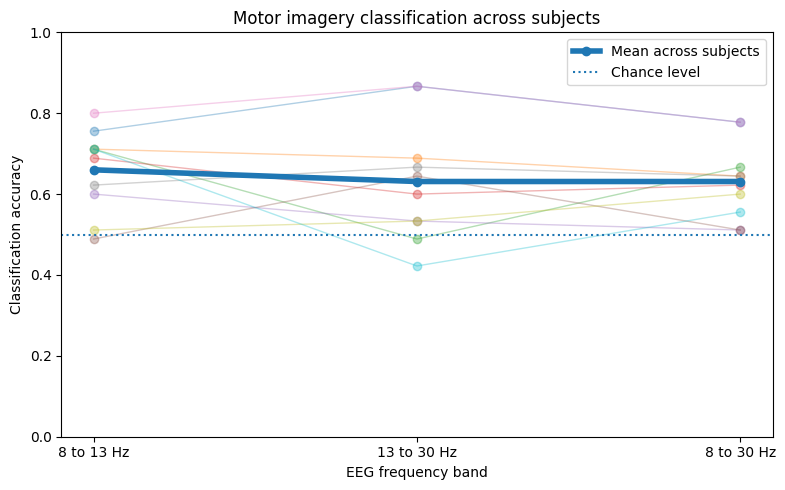

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import os

x = np.arange(len(results_df.columns))

plt.figure(figsize=(8, 5))

# Plot every subject
for subject, row in results_df.iterrows():
    plt.plot(
        x,
        row.values,
        marker="o",
        alpha=0.35,
        linewidth=1
    )

# Plot mean across subjects
means = results_df.mean()

plt.plot(
    x,
    means.values,
    marker="o",
    linewidth=4,
    label="Mean across subjects"
)

# Chance level for two class classification
plt.axhline(
    0.5,
    linestyle=":",
    label="Chance level"
)

plt.xticks(x, results_df.columns)
plt.ylabel("Classification accuracy")
plt.xlabel("EEG frequency band")
plt.title("Motor imagery classification across subjects")

plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

os.makedirs("figures", exist_ok=True)
plt.savefig(
    "figures/frequency_band_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()